In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Cell 2 — 2026 World Cup team data
teams_data = {
    'team': [
        'Brazil', 'France', 'Argentina', 'England', 'Germany',
        'Spain', 'Portugal', 'Netherlands', 'Belgium', 'Croatia',
        'Uruguay', 'Colombia', 'Mexico', 'USA', 'Senegal',
        'Morocco', 'Japan', 'South Korea', 'Australia', 'Canada',
        'Switzerland', 'Denmark', 'Poland', 'Serbia', 'Ukraine',
        'Turkey', 'Austria', 'Czech Republic', 'Hungary', 'Scotland',
        'Ecuador', 'Peru', 'Chile', 'Venezuela', 'Paraguay',
        'Bolivia', 'Nigeria', 'Cameroon', 'Ghana', 'Egypt',
        'Algeria', 'Tunisia', 'Saudi Arabia', 'Iran', 'Qatar',
        'Uzbekistan', 'Jordan', 'Cape Verde'
    ],
    'confederation': [
        'CONMEBOL','UEFA','CONMEBOL','UEFA','UEFA',
        'UEFA','UEFA','UEFA','UEFA','UEFA',
        'CONMEBOL','CONMEBOL','CONCACAF','CONCACAF','CAF',
        'CAF','AFC','AFC','AFC','CONCACAF',
        'UEFA','UEFA','UEFA','UEFA','UEFA',
        'UEFA','UEFA','UEFA','UEFA','UEFA',
        'CONMEBOL','CONMEBOL','CONMEBOL','CONMEBOL','CONMEBOL',
        'CONMEBOL','CAF','CAF','CAF','CAF',
        'CAF','CAF','AFC','AFC','AFC',
        'AFC','AFC','CAF'
    ],
    'fifa_ranking': [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15,
        16, 17, 18, 19, 20,
        21, 22, 23, 24, 25,
        26, 27, 28, 29, 30,
        31, 32, 33, 34, 35,
        36, 37, 38, 39, 40,
        41, 42, 43, 44, 45,
        46, 47, 48
    ],
    'world_cup_titles': [
        5, 2, 3, 1, 4,
        1, 0, 0, 0, 0,
        2, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        0, 0, 0
    ],
    'avg_age': [
        26, 27, 28, 26, 25,
        24, 29, 26, 29, 28,
        27, 26, 25, 24, 25,
        26, 25, 27, 26, 24,
        27, 25, 27, 25, 26,
        24, 26, 26, 27, 27,
        26, 28, 29, 24, 26,
        25, 25, 26, 27, 28,
        27, 26, 26, 27, 26,
        23, 25, 26
    ]
}

df = pd.DataFrame(teams_data)
print(f"Dataset created: {len(df)} teams")
print(df.head(10))

Dataset created: 48 teams
          team confederation  fifa_ranking  world_cup_titles  avg_age
0       Brazil      CONMEBOL             1                 5       26
1       France          UEFA             2                 2       27
2    Argentina      CONMEBOL             3                 3       28
3      England          UEFA             4                 1       26
4      Germany          UEFA             5                 4       25
5        Spain          UEFA             6                 1       24
6     Portugal          UEFA             7                 0       29
7  Netherlands          UEFA             8                 0       26
8      Belgium          UEFA             9                 0       29
9      Croatia          UEFA            10                 0       28


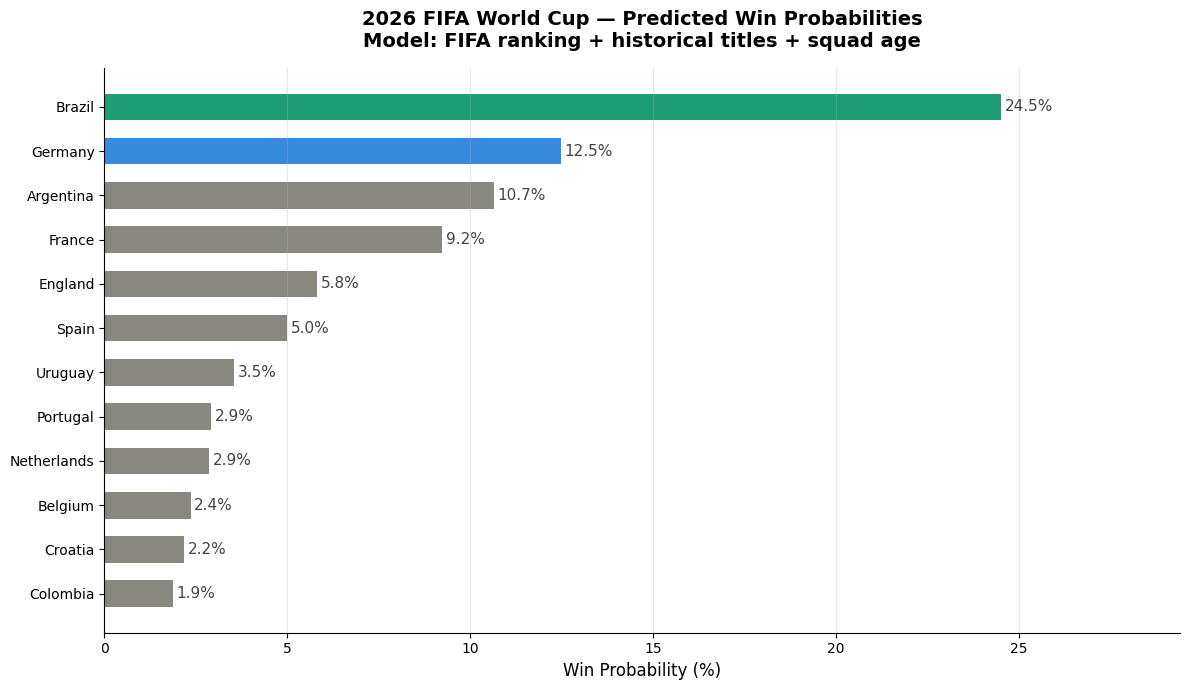

Chart saved as worldcup_2026_predictions.png


In [4]:
# Cell 3 — prediction model + chart
np.random.seed(42)

# calculate a win score for each team based on weighted features
df['ranking_score'] = (48 - df['fifa_ranking']) / 47 * 100
df['title_score'] = df['world_cup_titles'] * 8
df['youth_score'] = (30 - df['avg_age']) * 2
df['win_score'] = (df['ranking_score'] * 0.50 +
                   df['title_score'] * 0.35 +
                   df['youth_score'] * 0.15)

# convert to probability using softmax
scores = df['win_score'].values
exp_scores = np.exp(scores / 10)
df['win_probability'] = (exp_scores / exp_scores.sum()) * 100

# top 12 teams
top12 = df.nlargest(12, 'win_probability').reset_index(drop=True)

# chart
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#1D9E75' if i == 0 else '#378ADD' if i == 1 else '#888780' for i in range(len(top12))]
bars = ax.barh(top12['team'][::-1], top12['win_probability'][::-1], color=colors[::-1], height=0.6)

# add percentage labels
for bar, prob in zip(bars, top12['win_probability'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{prob:.1f}%', va='center', fontsize=11, color='#444')

ax.set_xlabel('Win Probability (%)', fontsize=12)
ax.set_title('2026 FIFA World Cup — Predicted Win Probabilities\nModel: FIFA ranking + historical titles + squad age',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top12['win_probability'].max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('worldcup_2026_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as worldcup_2026_predictions.png")

In [5]:
# Cell 4 — Monte Carlo simulation (10,000 runs)
np.random.seed(42)
SIMULATIONS = 10000
win_counts = {team: 0 for team in df['team']}

probs = df['win_probability'].values / 100
teams_list = df['team'].values

for _ in range(SIMULATIONS):
    winner = np.random.choice(teams_list, p=probs)
    win_counts[winner] += 1

df['simulated_win_pct'] = df['team'].map(win_counts) / SIMULATIONS * 100
top10_sim = df.nlargest(10, 'simulated_win_pct').reset_index(drop=True)

print(f"Simulation complete — {SIMULATIONS:,} tournaments run")
print("\nTop 10 predicted winners:")
for _, row in top10_sim.iterrows():
    bar = '█' * int(row['simulated_win_pct'] / 0.5)
    print(f"  {row['team']:<15} {row['simulated_win_pct']:5.1f}%  {bar}")

Simulation complete — 10,000 tournaments run

Top 10 predicted winners:
  Brazil           24.9%  █████████████████████████████████████████████████
  Germany          12.8%  █████████████████████████
  Argentina        11.0%  █████████████████████
  France            9.3%  ██████████████████
  England           5.8%  ███████████
  Spain             5.0%  ██████████
  Uruguay           3.5%  ███████
  Portugal          2.9%  █████
  Netherlands       2.8%  █████
  Belgium           2.1%  ████


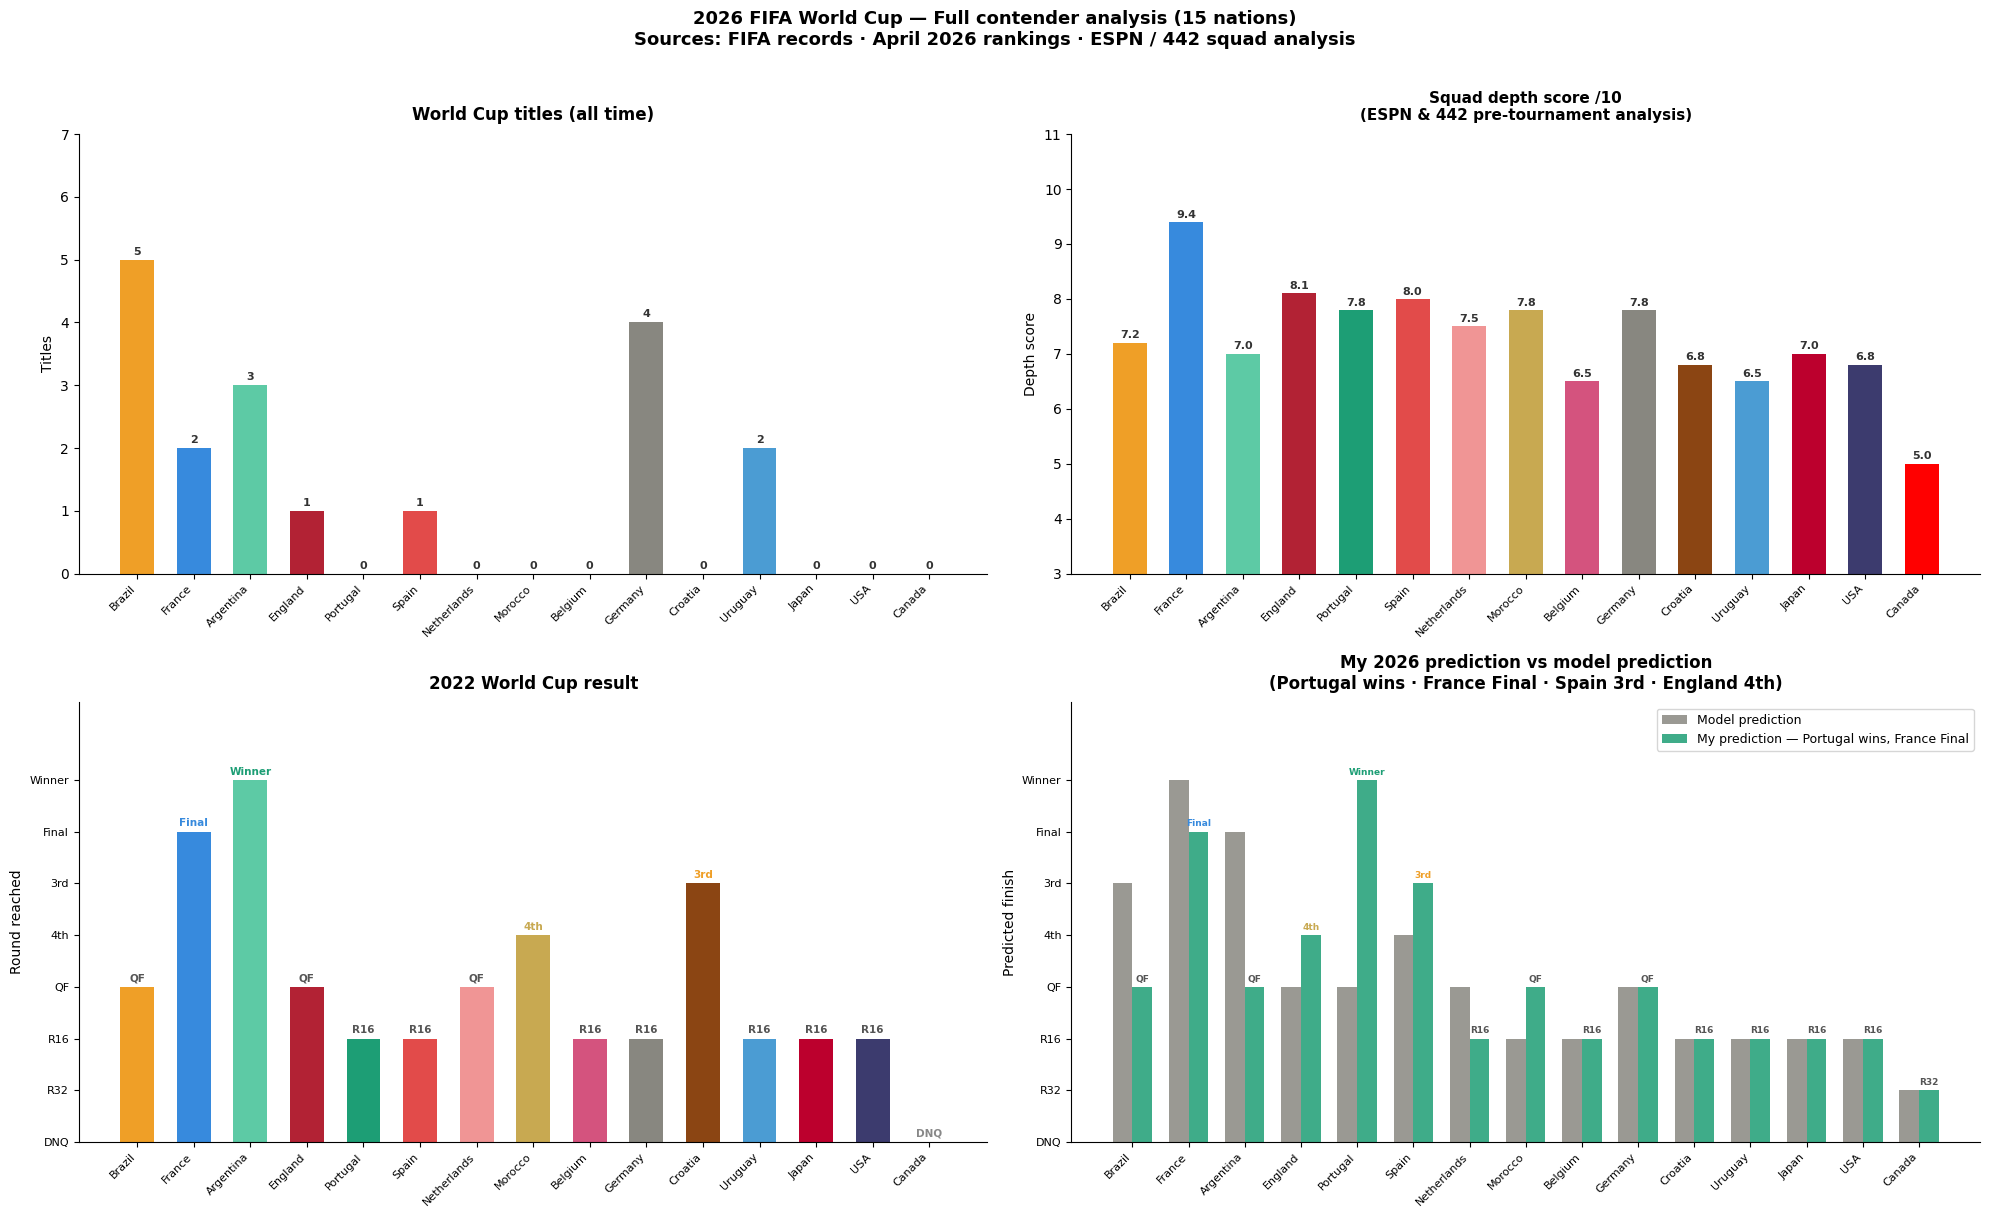

Saved.


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

nations = ['Brazil','France','Argentina','England','Portugal','Spain',
           'Netherlands','Morocco','Belgium','Germany',
           'Croatia','Uruguay','Japan','USA','Canada']

colors = ['#EF9F27','#378ADD','#5DCAA5','#B22234','#1D9E75','#E24B4A',
          '#F09595','#C8A951','#D4537E','#888780',
          '#8B4513','#4B9CD3','#BC002D','#3C3B6E','#FF0000']

wc_titles      = [5, 2, 3, 1, 0, 1, 0, 0, 0, 4, 0, 2, 0, 0, 0]
squad_depth    = [7.2, 9.4, 7.0, 8.1, 7.8, 8.0, 7.5, 7.8, 6.5, 7.8, 6.8, 6.5, 7.0, 6.8, 5.0]

wc_2022_score  = [3, 6, 7, 3, 2, 2, 3, 4, 2, 2, 5, 2, 2, 2, 0]
wc_2022_label  = ['QF','Final','Winner','QF','R16','R16','QF','4th','R16','R16','3rd','R16','R16','R16','DNQ']

# my prediction: Portugal winner, France final, Spain 3rd, England 4th
my_pred_score  = [3, 6, 3, 4, 7, 5, 2, 3, 2, 3, 2, 2, 2, 2, 1]
my_pred_label  = ['QF','Final','QF','4th','Winner','3rd','R16','QF','R16','QF','R16','R16','R16','R16','R32']

model_pred_score = [5, 7, 6, 3, 3, 4, 3, 2, 2, 3, 2, 2, 2, 2, 1]
model_pred_label = ['3rd','Winner','Final','QF','QF','4th','QF','R16','R16','QF','R16','R16','R16','R16','R32']

x = list(range(len(nations)))

def add_labels(ax, vals, fmt='{}', offset=0.08):
    for i, v in enumerate(vals):
        ax.text(i, v + offset, fmt.format(v), ha='center', fontsize=8, fontweight='bold', color='#333')

result_ticks      = [0, 1, 2, 3, 4, 5, 6, 7]
result_ticklabels = ['DNQ','R32','R16','QF','4th','3rd','Final','Winner']
highlight = {'Winner':'#1D9E75','Final':'#378ADD','3rd':'#EF9F27','4th':'#C8A951'}

# chart 1 — WC titles
ax1 = axes[0, 0]
ax1.bar(x, wc_titles, color=colors, width=0.6)
ax1.set_title('World Cup titles (all time)', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylim(0, 7)
ax1.set_ylabel('Titles')
ax1.set_xticks(x)
ax1.set_xticklabels(nations, rotation=45, ha='right', fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
add_labels(ax1, wc_titles)

# chart 2 — squad depth
ax2 = axes[0, 1]
ax2.bar(x, squad_depth, color=colors, width=0.6)
ax2.set_title('Squad depth score /10\n(ESPN & 442 pre-tournament analysis)', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylim(3, 11)
ax2.set_ylabel('Depth score')
ax2.set_xticks(x)
ax2.set_xticklabels(nations, rotation=45, ha='right', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
add_labels(ax2, squad_depth, fmt='{:.1f}')

# chart 3 — 2022 actual result
ax3 = axes[1, 0]
ax3.bar(x, wc_2022_score, color=colors, width=0.6)
ax3.set_title('2022 World Cup result', fontsize=12, fontweight='bold', pad=10)
ax3.set_ylim(0, 8.5)
ax3.set_ylabel('Round reached')
ax3.set_yticks(result_ticks)
ax3.set_yticklabels(result_ticklabels, fontsize=8)
ax3.set_xticks(x)
ax3.set_xticklabels(nations, rotation=45, ha='right', fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
for i, label in enumerate(wc_2022_label):
    col = highlight.get(label, '#888' if label == 'DNQ' else '#555')
    ax3.text(i, wc_2022_score[i] + 0.1, label, ha='center', fontsize=7.5, fontweight='bold', color=col)

# chart 4 — my prediction vs model
ax4 = axes[1, 1]
width = 0.35
ax4.bar([i - width/2 for i in x], model_pred_score, width, label='Model prediction', color='#888780', alpha=0.85)
ax4.bar([i + width/2 for i in x], my_pred_score,    width, label='My prediction — Portugal wins, France Final', color='#1D9E75', alpha=0.85)
ax4.set_title('My 2026 prediction vs model prediction\n(Portugal wins · France Final · Spain 3rd · England 4th)',
              fontsize=12, fontweight='bold', pad=10)
ax4.set_ylabel('Predicted finish')
ax4.set_ylim(0, 8.5)
ax4.set_yticks(result_ticks)
ax4.set_yticklabels(result_ticklabels, fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels(nations, rotation=45, ha='right', fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.legend(fontsize=9)
for i, label in enumerate(my_pred_label):
    col = highlight.get(label, '#555')
    ax4.text(i + width/2, my_pred_score[i] + 0.1, label, ha='center', fontsize=6.5, fontweight='bold', color=col)

plt.suptitle('2026 FIFA World Cup — Full contender analysis (15 nations)\nSources: FIFA records · April 2026 rankings · ESPN / 442 squad analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('worldcup_2026_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")